# Diseño del Modelo de la Bodegas de Datos

## Modelo Escogido: Estrella.

### Justificación
El modelo estrella ha sido seleccionado debido a su simplicidad y eficiencia en la consulta de datos. Su estructura facilita la optimización de consultas analíticas, reduciendo la complejidad de las uniones y mejorando el rendimiento.

### Modelo:

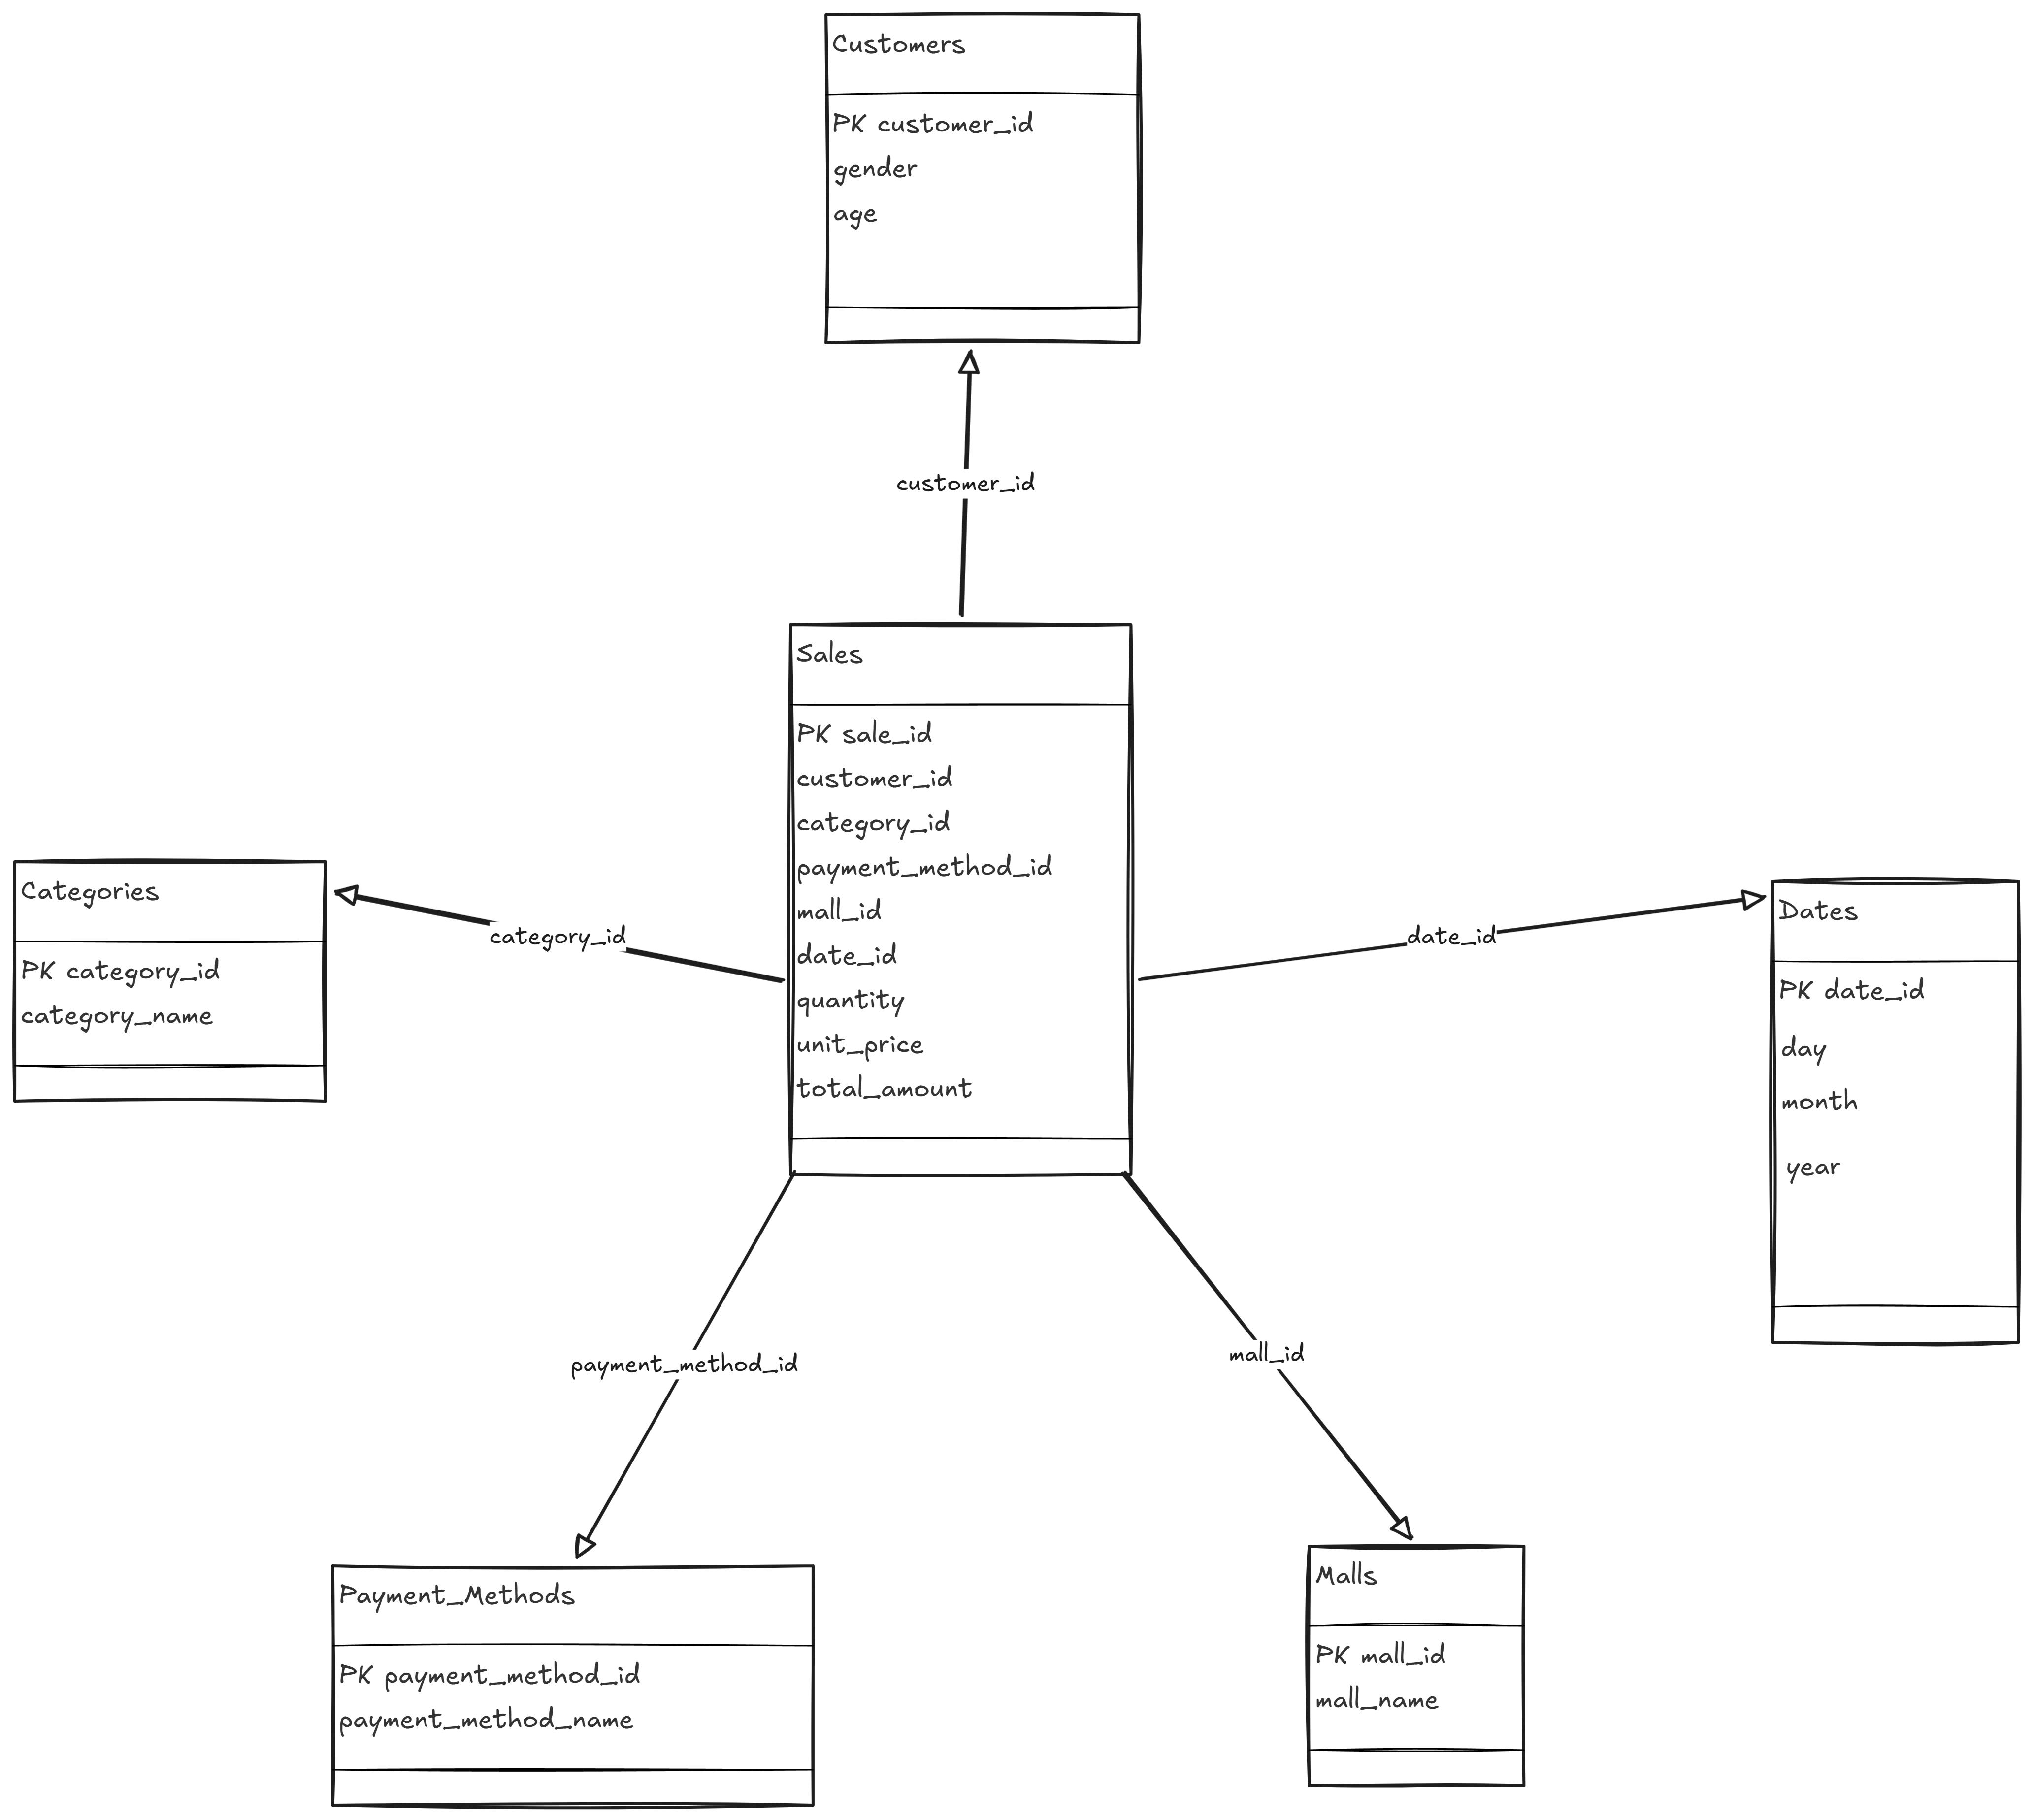

In [15]:
# Punto 2 
import pandas as pd
from  sqlalchemy import create_engine, text
from datetime import datetime
import sys, os


In [16]:
# Configuración base de datos
DB_CONFIG = { 'host': 'localhost', 'port': 5432, 'database': 'bodega_ventas_db', 'user': 'postgres', 'password': 'password' }
SCHEMA = 'shopping'
CSV_PATH = "customer_shopping_data.csv"

In [17]:
# Extracción de datos desde CSV

def extract_data(csv_path):
    print("Extrayendo datos del archivo CSV...")
    df = pd.read_csv(csv_path)
    print(f"Filas extraídas: {len(df):,}")
    print(f"Columnas extraídas: {len(df.columns)}")
    print(f"Celdas Nulas : \n{df.isnull().sum()}")
    return df


In [22]:
# Transformación de datos

def transform_data(df: pd.DataFrame) -> dict:
    print ("Transformando datos...")
    # limpieza de string
    for col in ["gender", "category", "payment_method", "shopping_mall", "customer_id"]:
        df[col] = df[col].str.strip().str.lower()
    
    # convertir fecha a formato datetime
    df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="mixed")
    # Fechas invalidas
    invalidas = df["invoice_date"].isnull().sum()
    if invalidas: 
        print(f"Fechas inválidas encontradas: {invalidas}")
        df = df.dropna(subset=["invoice_date"])

    # Empleados únicos 
    customers = (df[["customer_id", "gender", "age"]]
                    .drop_duplicates("customer_id")
                    .reset_index(drop=True))
    print(f"Clientes únicos: {len(customers):,} filas")

    # Categorías únicas
    categories = (df[["category"]]
                    .drop_duplicates("category")
                    .reset_index(drop=True))
    print(f"Categorías únicas: {len(categories):,} filas")

    # Días unicos 
    dates = (
        df["invoice_date"]
        .drop_duplicates()
        .to_frame()
        .assign(
            day   = lambda x: x["invoice_date"].dt.day,
            month = lambda x: x["invoice_date"].dt.month,
            year  = lambda x: x["invoice_date"].dt.year,
        )
        .drop(columns="invoice_date")
        .drop_duplicates(subset=["day", "month", "year"])
        .reset_index(drop=True)
    )
    print(f"Días únicos: {len(dates):,} filas")

    # Metodos de pago únicos
    payment_methods = (df[["payment_method"]]
                        .drop_duplicates("payment_method")
                        .rename(columns={"payment_method": "payment_method_name"})
                        .reset_index(drop=True))
    print(f"Métodos de pago únicos: {len(payment_methods):,} filas")

    # Centros comerciales únicos
    shopping_malls = (df[["shopping_mall"]]
                        .drop_duplicates("shopping_mall")
                        .rename(columns={"shopping_mall": "shopping_mall_name"})
                        .reset_index(drop=True))
    print(f"Centros comerciales únicos: {len(shopping_malls):,} filas")


    # Tabla de hechos 

    sales_raw = df[[
        "customer_id", "category", "payment_method",
        "shopping_mall", "invoice_date", "quantity", "price"
    ]].copy().rename(columns={"price": "unit_price"})
    print(f"  Sales raw       : {len(sales_raw):,} filas")

    return {
        "customers":       customers,
        "categories":      categories,
        "dates":           dates,
        "payment_methods": payment_methods,
        "malls":           shopping_malls,
        "sales_raw":       sales_raw,
    }

In [31]:
# Carga de datos a la base de datos

def load_data(tables:dict, engine):
    print("crear esquema y tablas...")
    with engine.begin() as conn:
        conn.execute(text("""
            CREATE SCHEMA IF NOT EXISTS shopping;
            SET search_path TO shopping;

            CREATE TABLE IF NOT EXISTS Customers (
                customer_id   VARCHAR(20)  PRIMARY KEY,
                gender        VARCHAR(10)  NOT NULL,
                age           INT          NOT NULL
            );

            CREATE TABLE IF NOT EXISTS Categories (
                category_id   SERIAL       PRIMARY KEY,
                category_name VARCHAR(60)  NOT NULL UNIQUE
            );

            CREATE TABLE IF NOT EXISTS Dates (
                date_id   SERIAL  PRIMARY KEY,
                day       INT     NOT NULL,
                month     INT     NOT NULL,
                year      INT     NOT NULL,
                UNIQUE (day, month, year)
            );

            CREATE TABLE IF NOT EXISTS Payment_Methods (
                payment_method_id   SERIAL       PRIMARY KEY,
                payment_method_name VARCHAR(30)  NOT NULL UNIQUE
            );

            CREATE TABLE IF NOT EXISTS Malls (
                mall_id    SERIAL       PRIMARY KEY,
                mall_name  VARCHAR(100) NOT NULL UNIQUE
            );

            CREATE TABLE IF NOT EXISTS Sales (
                sale_id           SERIAL         PRIMARY KEY,
                customer_id       VARCHAR(20)    NOT NULL REFERENCES Customers(customer_id),
                category_id       INT            NOT NULL REFERENCES Categories(category_id),
                payment_method_id INT            NOT NULL REFERENCES Payment_Methods(payment_method_id),
                mall_id           INT            NOT NULL REFERENCES Malls(mall_id),
                date_id           INT            NOT NULL REFERENCES Dates(date_id),
                quantity          INT            NOT NULL,
                unit_price        NUMERIC(12,2)  NOT NULL,
                total_amount      NUMERIC(12,2)  GENERATED ALWAYS AS (quantity * unit_price) STORED
            );
    """))
    print("Cargando datos a la base de datos...")
    with engine.begin() as conn:
        conn.execute(text("TRUNCATE Sales, Customers, " \
        "Categories, Dates, Payment_Methods, Malls RESTART IDENTITY CASCADE"))

        dimensiones = [
            ("customers",       "Customers",       tables["customers"]),
            ("categories",      "Categories",      tables["categories"]),
            ("dates",           "Dates",           tables["dates"]),
            ("payment_methods", "Payment_Methods", tables["payment_methods"]),
            ("malls",           "Malls",           tables["malls"]),]
        
        for key, table_name, df_dim in dimensiones:
            print(f"  Cargando dimensión {table_name}...")
            df_dim.to_sql(table_name, con=conn, 
                          schema=SCHEMA, 
                          if_exists="append", 
                          index=False,
                          method="multi",
                          chunksize=1000)
            print(f"  {table_name:<20} cargada : {len(df_dim):>6} filas")

        # LLave foránea para tabla de hechos

        category_keys  = pd.read_sql(f"SELECT category_id, category_name FROM {SCHEMA}.Categories", conn)
        date_keys      = pd.read_sql(f"SELECT date_id, day, month, year FROM {SCHEMA}.Dates", conn)
        payment_keys   = pd.read_sql(f"SELECT payment_method_id, payment_method_name FROM {SCHEMA}.Payment_Methods", conn)
        mall_keys      = pd.read_sql(f"SELECT mall_id, mall_name FROM {SCHEMA}.Malls", conn)

        sales = tables["sales_raw"].copy()

        # Extraer día, mes y año para merge con tabla de fechas
        sales["day"]   = sales["invoice_date"].dt.day
        sales["month"] = sales["invoice_date"].dt.month
        sales["year"]  = sales["invoice_date"].dt.year

        # Merge con dimensiones para obtener las FK
        sales = sales.merge(
            category_keys.rename(columns={"category_name": "category"}),
            on="category", how="left"
        )
        sales = sales.merge(
            date_keys, on=["day", "month", "year"], how="left"
        )
        sales = sales.merge(
            payment_keys.rename(columns={"payment_method_name": "payment_method"}),
            on="payment_method", how="left"
        )
        sales = sales.merge(
            mall_keys.rename(columns={"mall_name": "shopping_mall"}),
            on="shopping_mall", how="left"
        )

        # Verificar que no haya FK nulas antes de cargar la tabla de hechos
        fk_cols = ["category_id", "date_id", "payment_method_id", "mall_id"]
        missing = sales[fk_cols].isnull().sum()
        if missing.any():
            print(f"  ⚠ FK nulas detectadas:\n{missing[missing > 0]}")

        sales_final = sales[[
            "customer_id", "category_id", "payment_method_id",
            "mall_id", "date_id", "quantity", "unit_price"
        ]]

        sales_final.to_sql(
            "Sales", conn, schema=SCHEMA,
            if_exists="append", index=False,
            method="multi", chunksize=5000,
        )
        print(f"  {'Sales':<20} cargada : {len(sales_final):>6} filas")

In [24]:
# Verificación de datos cargados

def verify_data(engine)-> None:

    tables = ["Customers", "Categories", "Dates", "Payment_Methods", "Malls", "Sales"]
    with engine.connect() as conn:
        for table in tables:
            result = conn.execute(text(f"SELECT COUNT(*) FROM {SCHEMA}.{table}"))
            count = result.scalar()
            print(f"  {table:<20} filas en la base de datos: {count:,}")

    # joins para verificar integridad referencial

    q = f"""SELECT
            s.sale_id,
            c.customer_id,
            c.gender,
            c.age,
            cat.category_name,
            d.day, d.month, d.year,
            m.mall_name,
            pm.payment_method_name,
            s.quantity,
            s.unit_price,
            s.total_amount
        FROM {SCHEMA}.Sales           s
        JOIN {SCHEMA}.Customers        c   ON s.customer_id       = c.customer_id
        JOIN {SCHEMA}.Categories       cat ON s.category_id       = cat.category_id
        JOIN {SCHEMA}.Dates            d   ON s.date_id           = d.date_id
        JOIN {SCHEMA}.Malls            m   ON s.mall_id           = m.mall_id
        JOIN {SCHEMA}.Payment_Methods  pm  ON s.payment_method_id = pm.payment_method_id
        LIMIT 5
        """
    with engine.connect() as conn:
        sample = pd.read_sql(text(q), conn)
    print("\nMuestra de datos cargados (con joins):")
    print(sample.to_string(index=False))

In [ ]:
#Función principal 

def main():
    t0 = datetime.now()
    print("  ETL — Customer Shopping Dataset (Modelo diagrama)")
    print(f"  Inicio: {t0.strftime('%Y-%m-%d %H:%M:%S')}")

    conn_str = (
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
    )
    try:
        engine = create_engine(conn_str, echo=False)
        with engine.connect() as conn:
            conn.execute(text("SELECT 1"))
        print(f"\n[CONEXION] OK → {DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
    except Exception as e:
        print(f"\n[ERROR] Conexión fallida: {e}")
        sys.exit(1)

    raw    = extract_data(CSV_PATH)
    tables = transform_data(raw)
    load_data(tables, engine)
    verify_data(engine)

    elapsed = (datetime.now() - t0).total_seconds()
    print(f"\n{'='*60}")
    print(f"  ETL completado en {elapsed:.1f} segundos.")
   


if __name__ == "__main__":
    main()
